In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("mnist.csv")
df.head

<bound method NDFrame.head of       label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0         7    0    0    0    0    0    0    0    0    0  ...      0      0   
1         2    0    0    0    0    0    0    0    0    0  ...      0      0   
2         1    0    0    0    0    0    0    0    0    0  ...      0      0   
3         0    0    0    0    0    0    0    0    0    0  ...      0      0   
4         4    0    0    0    0    0    0    0    0    0  ...      0      0   
...     ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
9995      2    0    0    0    0    0    0    0    0    0  ...      0      0   
9996      3    0    0    0    0    0    0    0    0    0  ...      0      0   
9997      4    0    0    0    0    0    0    0    0    0  ...      0      0   
9998      5    0    0    0    0    0    0    0    0    0  ...      0      0   
9999      6    0    0    0    0    0    0    0    0    0  ...      0      0   

      28x21  28x22  2

In [5]:
df.shape

(10000, 785)

In [6]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='str', length=785)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


In [10]:
df.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,10000.000000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,4.443400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179300,0.163600,0.052600,0.0006,0.0,0.0,0.0,0.0,0.0,0.0
std,2.895865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674149,5.736072,2.420004,0.0600,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

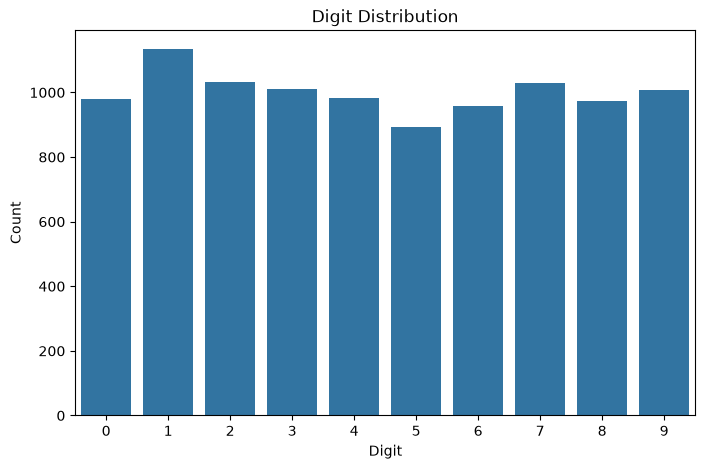

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="label")

plt.title("Digit Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")

plt.show()

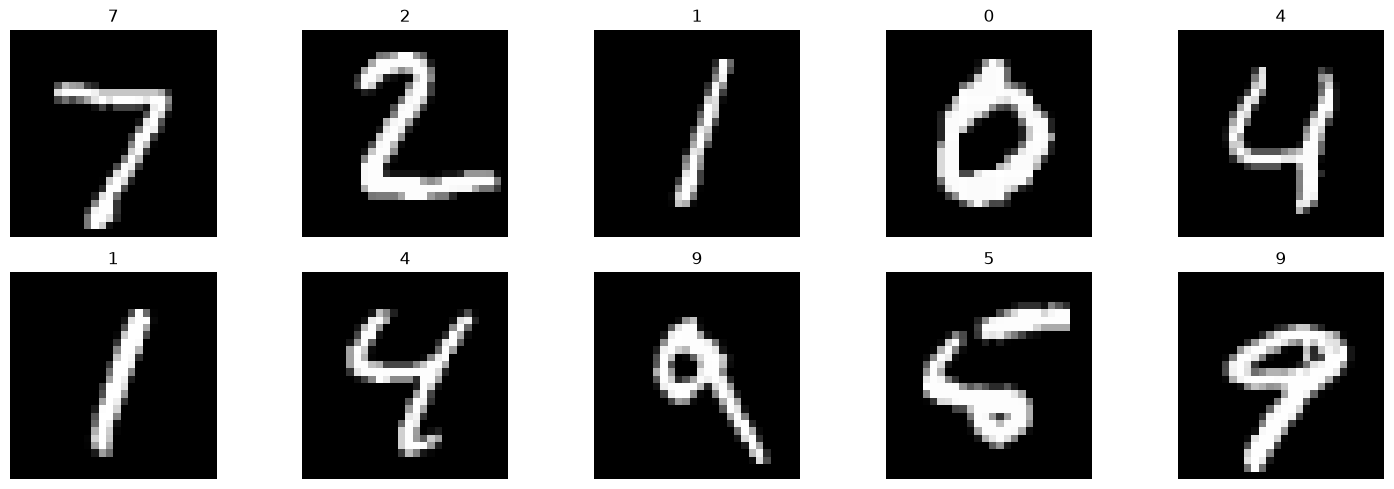

In [14]:
plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    image = df.iloc[i,1:].values.reshape(28,28)

    plt.imshow(image,cmap="gray")

    plt.title(df.iloc[i,0])

    plt.axis("off")

plt.tight_layout()

plt.show()

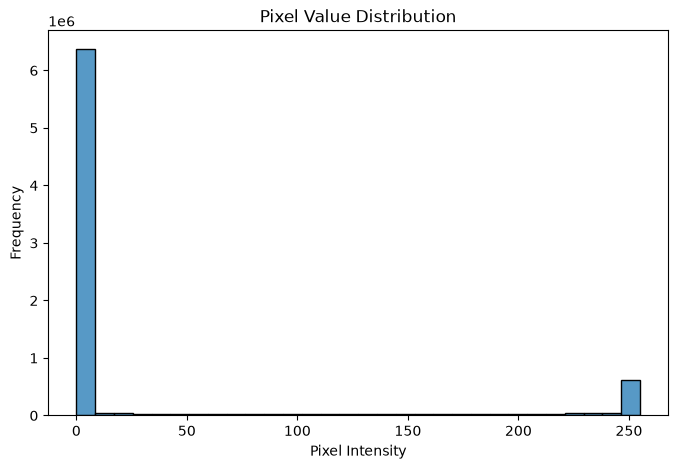

In [15]:
pixels = df.iloc[:,1:].values.flatten()

plt.figure(figsize=(8,5))

sns.histplot(
    pixels,
    bins=30
)

plt.title("Pixel Value Distribution")

plt.xlabel("Pixel Intensity")

plt.ylabel("Frequency")

plt.show()

In [16]:
X = df.drop("label",axis=1)

y = df["label"]

In [17]:
X = X / 255.0

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

In [37]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score

print("Logistic Regression :",accuracy_score(y_test,lr_pred))


print("Random Forest :",accuracy_score(y_test,rf_pred))

print("KNN :",accuracy_score(y_test,knn_pred))

print("SVM :",accuracy_score(y_test,svm_pred))

Logistic Regression : 0.908
Random Forest : 0.955
KNN : 0.943
SVM : 0.9635


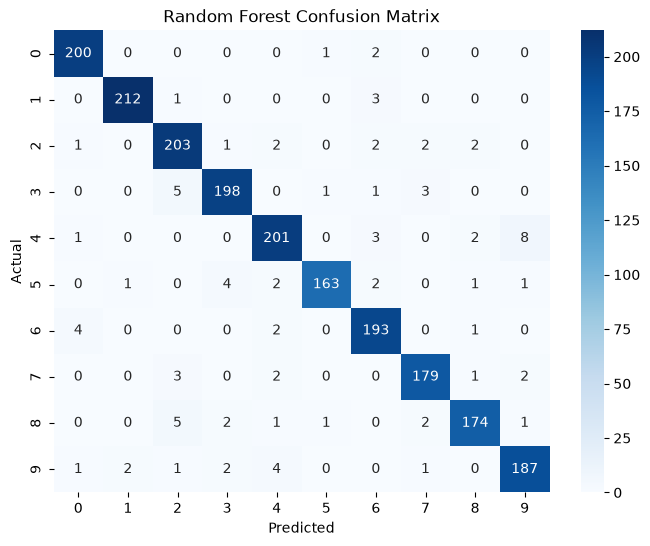

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test,rf_pred))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       203
           1       0.99      0.98      0.98       216
           2       0.93      0.95      0.94       213
           3       0.96      0.95      0.95       208
           4       0.94      0.93      0.94       215
           5       0.98      0.94      0.96       174
           6       0.94      0.96      0.95       200
           7       0.96      0.96      0.96       187
           8       0.96      0.94      0.95       186
           9       0.94      0.94      0.94       198

    accuracy                           0.95      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.96      0.95      0.96      2000



In [42]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Random Forest",

        "KNN",

        "SVM"

    ],

    "Accuracy":[

        accuracy_score(y_test,lr_pred),

        accuracy_score(y_test,rf_pred),

        accuracy_score(y_test,knn_pred),

        accuracy_score(y_test,svm_pred)

    ]

})

results

,Model,Accuracy
0,Logistic Regression,0.9080
1,Random Forest,0.9550
2,KNN,0.9430
3,SVM,0.9635


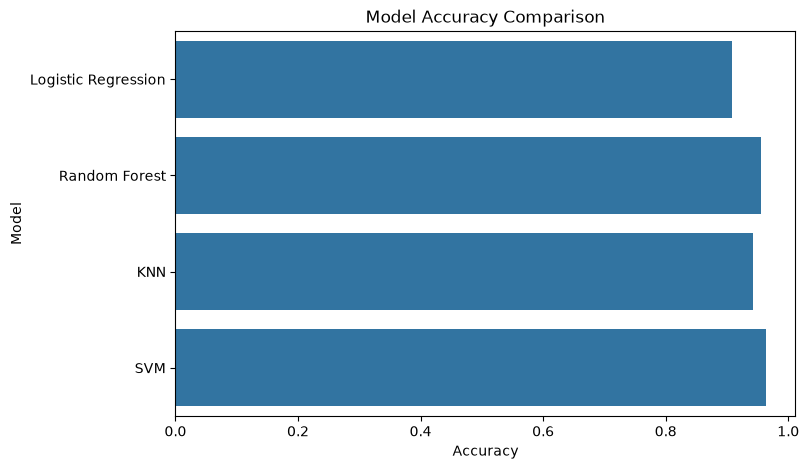

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=results,

    x="Accuracy",

    y="Model"

)

plt.title("Model Accuracy Comparison")

plt.show()

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    rf,

    X,

    y,

    cv=5

)

print(scores)

print("Average Accuracy :",scores.mean())

[0.9275 0.9255 0.9465 0.9615 0.9695]
Average Accuracy : 0.9461
